# Cytokines ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sksurv.util import Surv
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.ensemble import RandomSurvivalForest, ComponentwiseGradientBoostingSurvivalAnalysis, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc, concordance_index_ipcw
from sksurv.compare import compare_survival
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

In [2]:
print(plt.rcParams["font.family"])
plt.rcParams["font.sans-serif"] = ["Arial"] + plt.rcParams["font.sans-serif"]

['sans-serif']


In [3]:
# Load formatted cytokines data
df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260731.csv")

In [4]:
# Encode survival status as binary variable
df["survival_status_encoded"] = df["survival_status"].map({"alive": 0, "death": 1})

In [5]:
# Map string labels to boolean: True = death observed, False = alive
event_observed = df["survival_status"].map(
    {"death": True, "alive": False}
)

# Check for NA values in survival_status mapping
assert event_observed.isna().sum() == 0, (
    f"Unmapped survival_status values found: "
    f"{df['survival_status'][event_observed.isna()].unique()}"
)

# Create structured array for survival analysis
y = Surv.from_arrays(
        event=event_observed,
        time=df["sx_to_lastfu"]
    )

y

array([(False, 1839.), (False, 1721.), ( True,   48.), ( True,  131.),
       (False, 1679.), ( True,  318.), ( True,  278.), (False, 1765.),
       (False, 1758.), ( True,  997.), ( True,  482.), ( True,  592.),
       (False, 1625.), (False, 1592.), (False, 1406.), ( True,   84.),
       ( True,  253.), ( True,   51.), (False, 1582.), (False, 1510.),
       (False, 1500.), (False, 1485.), (False, 1410.), (False, 1475.),
       ( True,  689.), ( True, 1055.), ( True,  433.), (False,  634.),
       ( True,  665.), (False, 1268.), ( True,  330.), (False, 1274.),
       (False, 1282.), (False,  765.), (False, 1123.), (False, 1094.),
       ( True,  618.), ( True,  490.), (False, 1137.), (False, 1095.),
       (False, 1050.), ( True,  494.), ( True,  597.), (False, 1085.),
       ( True,  379.), ( True,  355.), (False, 1078.), ( True,  385.),
       ( True,   87.), ( True,  763.), (False,  907.), (False,  814.),
       (False, 1018.), (False, 1014.), (False,  945.), (False,  631.),
      

In [6]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "ages", "sex", "race", "tobaccouse", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

In [7]:
# Subset cytokines and cohort columns for analysis
cytokines_df = df.loc[:, cytokines + ["cohort", "ss", "survival_status_encoded"]].drop(columns=["tgfalpha", "hbegf"])
cytokines_df

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,cohort,ss,survival_status_encoded
0,29.45,25.24,90.00,6.40,3.95,4.21,3.54,4.14,3.92,25.93,18.74,10.46,381.47,263.05,LLU,1,0
1,71.50,9.93,46.35,0.00,0.00,2.33,3.42,4.53,75.20,2.90,25.54,3.74,923.75,237.53,LLU,4,0
2,54.54,18.38,54.01,46.49,18.90,1.37,4.15,3.57,98.33,25.05,22.39,4.83,490.19,130.47,LLU,4,1
3,132.67,27.47,81.82,6.89,3.95,4.56,9.69,7.29,20.63,20.32,28.18,9.32,1148.22,34.22,LLU,3,1
4,28.01,13.63,66.20,5.44,0.92,3.04,2.42,5.44,10.63,17.14,39.61,5.94,1113.45,142.55,LLU,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,61.90,122.36,103.74,552.31,15.62,5864.00,199.75,208.34,168.84,18.23,19.66,855.53,289.94,91.56,UAB,3,1
208,18.86,91.86,71.49,22.67,5.42,146.71,18.96,12.67,82.12,10.90,26.21,19.05,234.20,65.32,UAB,1,0
209,12.99,66.46,51.61,9.46,2.89,28.61,2.28,8.89,7.41,9.54,13.77,7.24,144.61,55.09,UAB,4,0
210,13.66,75.02,40.79,8.96,3.81,38.38,5.04,4.50,12.45,6.71,16.65,11.06,158.81,21.47,UAB,2,0


In [8]:
# Z-normalization of the cytokine values based on cohort (due to two different platforms on the two cohorts)
numeric_features = cytokines_df.columns.drop(["cohort", "survival_status_encoded"])

sc = StandardScaler()

cytokines_standardization_df = cytokines_df.copy()
cytokines_standardization_df[numeric_features] = (
    cytokines_standardization_df.groupby("cohort")[numeric_features]
    .transform(lambda x: sc.fit_transform(x.to_numpy().reshape(-1, 1)).ravel())
)

cytokines_standardization_df

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,cohort,ss,survival_status_encoded
0,-0.148154,0.121418,1.409269,-0.236668,-0.106581,1.045099,-0.432814,-0.182359,-0.485307,0.100156,0.004131,0.184295,-0.556037,0.084989,LLU,-1.501561,0
1,0.869503,-0.238375,-0.121928,-0.423888,-0.426731,0.134685,-0.441613,-0.089010,0.215519,-0.262735,0.635905,-0.203060,1.079924,-0.022325,LLU,0.711266,0
2,0.459052,-0.039796,0.146777,0.936090,1.105124,-0.330206,-0.388083,-0.318792,0.442933,0.086290,0.343245,-0.140230,-0.228049,-0.472525,LLU,0.711266,1
3,2.349885,0.173824,1.122323,-0.222334,-0.106581,1.214591,0.018162,0.571611,-0.321014,0.011758,0.881182,0.118583,1.757109,-0.877267,LLU,-0.026343,1
4,-0.183004,-0.151423,0.574390,-0.264751,-0.352165,0.478512,-0.514943,0.128803,-0.419334,-0.038351,1.943120,-0.076247,1.652214,-0.421727,LLU,-1.501561,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,0.668459,1.483059,1.016899,5.716271,2.450417,6.584278,5.607206,5.541594,4.921763,3.000118,0.721482,5.664938,0.342350,-0.031358,UAB,0.355378,1
208,-0.507584,0.308943,0.342188,-0.328103,0.302498,-0.294040,0.058200,-0.261465,1.954145,0.676460,1.710124,-0.352185,-0.039353,-0.107783,UAB,-1.156869,0
209,-0.667978,-0.668846,-0.073727,-0.478858,-0.230269,-0.436123,-0.453761,-0.373570,-0.602483,0.245331,-0.167541,-0.437138,-0.652859,-0.137579,UAB,1.111501,0
210,-0.649670,-0.339323,-0.300095,-0.484564,-0.036536,-0.424369,-0.369048,-0.503766,-0.430010,-0.651797,0.267160,-0.409660,-0.555618,-0.235499,UAB,-0.400745,0


In [10]:
def univariate_roc_grouping(df, cols, outcome_col):
    """
    For each column in `cols`, compute AUC vs `outcome_col`, determine
    association direction, find the Youden's J optimal threshold, and
    assign high/low group labels accordingly.

    Returns:
        results_df: summary table with AUC, direction, threshold per variable
        df: original dataframe with new f"{col}_group" columns added
    """
    results = []

    for col in cols:
        # drop rows with missing values for this column/outcome pair
        valid = df[[col, outcome_col]].dropna()
        y_true = valid[outcome_col].values
        score = valid[col].values

        if len(np.unique(y_true)) < 2:
            print(f"Skipping {col}: outcome has only one class after dropping NaNs")
            continue

        # AUC and direction
        auc = roc_auc_score(y_true, score)
        direction = "positive" if auc >= 0.5 else "negative"

        # Flip the score for ROC computation if direction is negative,
        # so Youden's J finds a meaningful maximum instead of the
        # degenerate inf/-inf threshold.
        roc_score = score if direction == "positive" else -score

        # ROC curve + Youden's J optimal threshold
        fpr, tpr, thresholds = roc_curve(y_true, roc_score)
        youden_j = tpr - fpr
        best_idx = np.argmax(youden_j)
        best_threshold = thresholds[best_idx]
        sensitivity = tpr[best_idx]
        specificity = 1 - fpr[best_idx]

        # assign high/low based on direction:
        # positive association -> higher values = "high" risk/group
        # negative association -> lower values = "high" risk/group
        if direction == "positive":
            group = np.where(df[col] > best_threshold, "high", "low")
        else:
            group = np.where(df[col] > best_threshold, "low", "high")

        df[f"{col}_group"] = group

        results.append({
            "variable": col,
            "auc": auc,
            "auc_abs": max(auc, 1 - auc),
            "direction": direction,
            "best_threshold": best_threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "n": len(valid),
        })

    results_df = pd.DataFrame(results).sort_values("auc_abs", ascending=False).reset_index(drop=True)
    return results_df, df

# Function call
outcome_col = "survival_status_encoded"

roc_summary, cytokines_standardization_df = univariate_roc_grouping(cytokines_standardization_df, numeric_features, outcome_col)

print(roc_summary)
print(cytokines_standardization_df[[f"{c}_group" for c in numeric_features]].apply(pd.Series.value_counts))

     variable       auc   auc_abs direction  best_threshold  sensitivity  \
0          ss  0.749363  0.749363  positive       -0.026343     0.864865   
1       vegfd  0.365306  0.634694  negative        0.247383     0.445946   
2         il6  0.625294  0.625294  positive       -0.421840     0.729730   
3         il8  0.611584  0.611584  positive       -0.431402     0.770270   
4    tnfalpha  0.581962  0.581962  positive       -0.117731     0.567568   
5        il10  0.577801  0.577801  positive       -0.444383     0.810811   
6    il1alpha  0.558020  0.558020  positive       -0.399772     0.581081   
7     tnfbeta  0.545584  0.545584  positive       -0.065295     0.351351   
8         egf  0.544653  0.544653  positive       -0.362764     0.554054   
9       vegfc  0.474050  0.525950  negative        0.729966     0.391892   
10  mip1alpha  0.520515  0.520515  positive       -0.115877     0.554054   
11  ifnalpha2  0.485067  0.514933  negative       -0.181579     0.797297   
12        il

## Univariate Kaplan-Meier Survival Curves

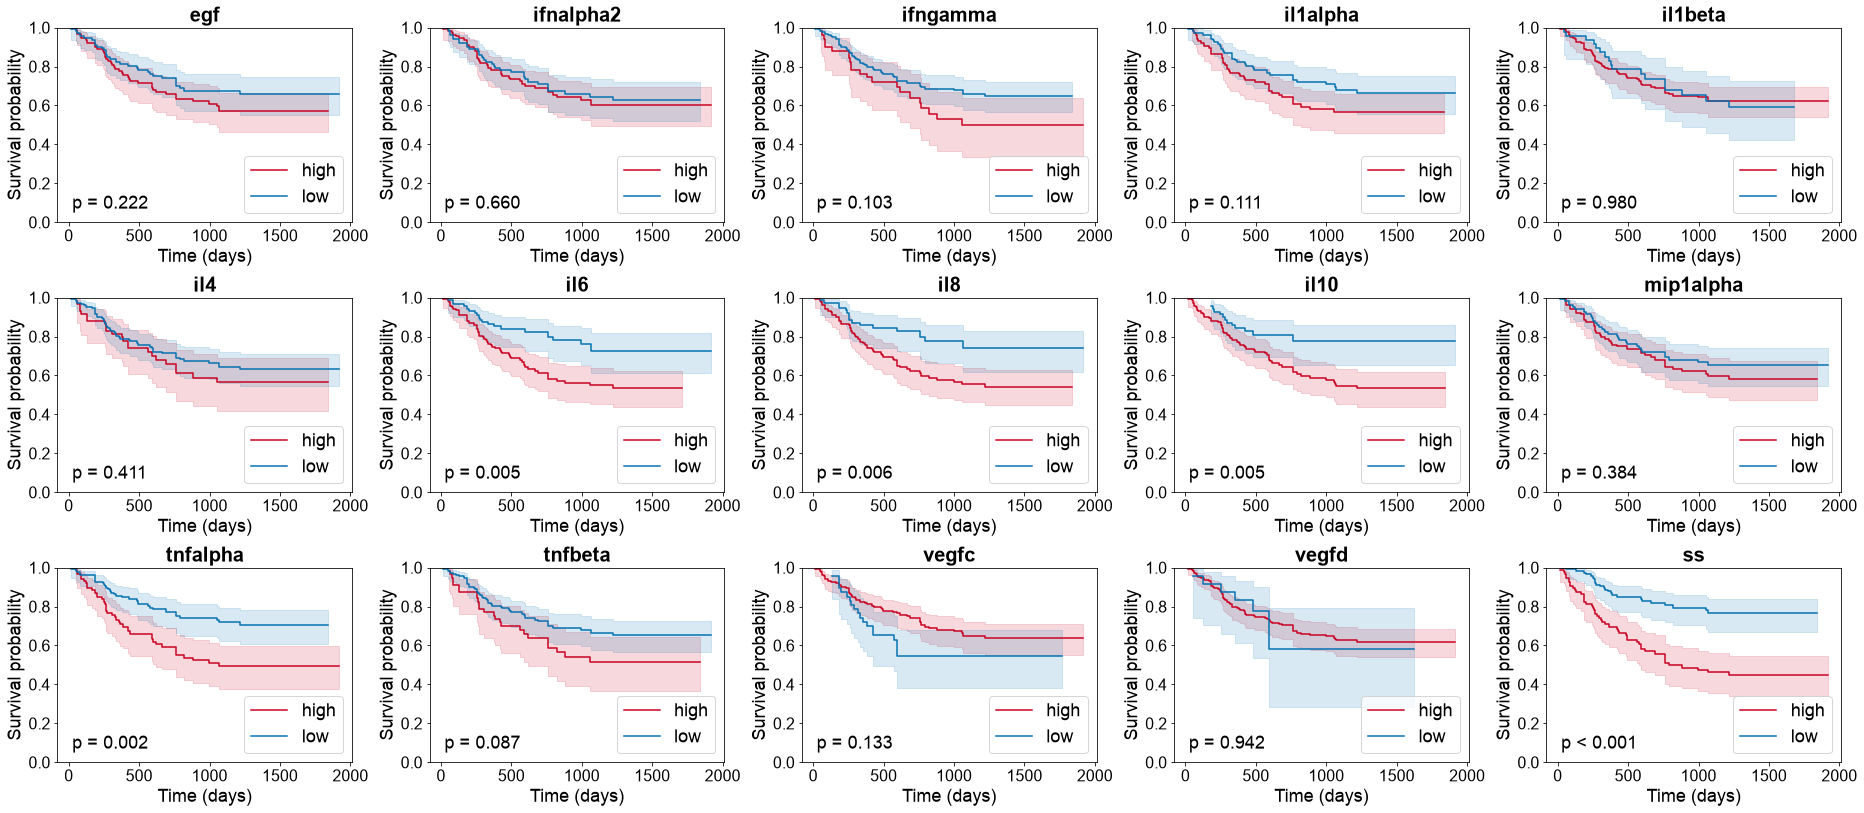

In [11]:
# Function to plot Kaplan-Meier survival curves in a grid, one panel per grouping variable
def plot_km_grid(df, y, group_cols, ncols=3, figsize_per_panel=(5.2, 3.8),
                          colors=("#CA0020", "#0571B0", "#4DAC26", "#FDB863", "#5E3C99"),
                          ci_alpha=0.15):
    """
    Plot Kaplan-Meier survival curves in a grid, one panel per grouping variable,
    using scikit-survival's kaplan_meier_estimator and compare_survival for the
    log-rank test.

    Parameters
    ----------
    df : DataFrame containing the group columns
    y : structured array with fields "event" (bool) and "time" (float),
        as used by scikit-survival (e.g. Surv.from_arrays(event, time))
    group_cols : list of column names in df to loop over
    """
    n = len(group_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0]*ncols, figsize_per_panel[1]*nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    # Force everything to plain numpy arrays, positionally aligned to df
    df = df.reset_index(drop=True)
    event_arr = np.asarray(y["event"]).reshape(-1)
    time_arr = np.asarray(y["time"]).reshape(-1)

    assert len(event_arr) == len(df), f"event length {len(event_arr)} != df length {len(df)}"
    assert len(time_arr) == len(df), f"time length {len(time_arr)} != df length {len(df)}"

    for i, col in enumerate(group_cols):
        ax = axes[i]
        col_vals = df[col].to_numpy()
        valid = pd.notna(col_vals)
        groups = sorted(pd.unique(col_vals[valid]))

        for g, color in zip(groups, colors):
            mask = valid & (col_vals == g)
            time_g, surv_prob_g, conf_int_g = kaplan_meier_estimator(
                event_arr[mask], time_arr[mask], conf_type="log-log"
            )
            ax.step(time_g, surv_prob_g, where="post", color=color, label=str(g))
            ax.fill_between(
                time_g, conf_int_g[0], conf_int_g[1],
                alpha=ci_alpha, step="post", color=color
            )

        # log-rank / chi-square test across groups (works for 2+ groups)
        _, p = compare_survival(y[valid], col_vals[valid])

        p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.text(
            0.05, 0.05, p_text, transform=ax.transAxes,
            fontsize=18, verticalalignment="bottom"
        )

        ax.set_ylim(0, 1)
        ax.set_title(col.replace("_group", ""), fontweight="bold", fontsize=20)
        ax.tick_params(axis="x", labelsize=16)
        ax.tick_params(axis="y", labelsize=16)
        ax.set_xlabel("Time (days)", fontsize=18)
        ax.set_ylabel("Survival probability", fontsize=18)
        ax.legend(fontsize=18, loc="lower right")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    return fig


# Plot the Kaplan-Meier curves for each cytokine grouping variable
group_cols = [f"{c}_group" for c in numeric_features]
fig = plot_km_grid(cytokines_standardization_df, y, group_cols, ncols=5)

fig.savefig("../figures/km_grid_sksurv.png", dpi=300, bbox_inches="tight")

## Multivariate Survival Models

In [12]:
# Specify the standardizednumeric features for the Cox model
X_full_standardized = cytokines_standardization_df[numeric_features]

In [13]:
# Fit Cox Proportional Hazards model to the transformed data
estimator = CoxPHSurvivalAnalysis()
estimator.fit(cytokines_standardization_df[numeric_features], y)

,alpha,0
,ties,'breslow'
,n_iter,100
,tol,1e-09
,verbose,0
Name,Type,Value
baseline_survival_,StepFunction,"StepFunction(... a=1.0, b=0.0)"
coef_,"ndarray[float64](15,)","[ 0.01, 0.03, 0.05,...,-0.03,-0.78, 0.83]"
cum_baseline_hazard_,StepFunction,"StepFunction(... a=1.0, b=0.0)"
feature_names_in_,"ndarray[object](15,)","['egf','ifnalpha2','ifngamma',...,'vegfc','vegfd','ss']"
n_features_in_,int,15


In [14]:
pd.Series(np.exp(estimator.coef_), index=X_full_standardized.columns)

egf          1.008831
ifnalpha2    1.026738
ifngamma     1.055820
il1alpha     0.963833
il1beta      0.996389
il4          1.222602
il6          1.428246
il8          1.290040
il10         0.541558
mip1alpha    1.002897
tnfalpha     1.403633
tnfbeta      0.836840
vegfc        0.967014
vegfd        0.459894
ss           2.284233
dtype: float64

In [15]:
# Evaluate the model using concordance index
prediction = estimator.predict(X_full_standardized)
result = concordance_index_censored(y["event"], y["time"], prediction)
f"{result[0]:.5f}"

'0.74835'

In [16]:
# Concordance index for each feature using univariate Cox regression
def fit_and_score_features(X, y):
    n_features = X.shape[1]
    scores = np.empty(n_features)
    m = CoxPHSurvivalAnalysis()
    for j in range(n_features):
        Xj = X[:, j : j + 1]
        m.fit(Xj, y)
        scores[j] = m.score(Xj, y)
    return scores


scores = fit_and_score_features(X_full_standardized.values, y)

c_index_scores_df = (
    pd.Series(scores, index=X_full_standardized.columns)
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index(name="c_index_score")
)

c_index_scores_df

,feature,c_index_score
0,ss,0.707020
1,vegfd,0.621814
2,il6,0.595153
3,tnfalpha,0.576264
4,il8,0.573255
5,il10,0.555077
6,tnfbeta,0.550564
7,il1alpha,0.541538
8,ifngamma,0.514960
9,ifnalpha2,0.513999


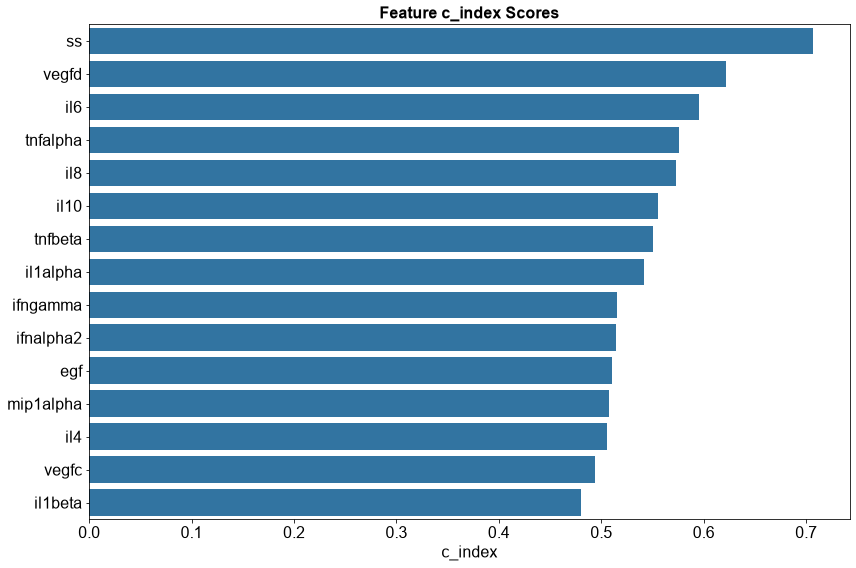

In [17]:
# Plot the c_index scores for each feature
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=c_index_scores_df,
    x="c_index_score",
    y="feature",
    order=c_index_scores_df["feature"],
    ax=ax
)

ax.set_xlabel("c_index", fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylabel("", fontsize=16)
ax.set_title("Feature c_index Scores", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

fig.savefig("../figures/feature_c_index_scores.png", dpi=300, bbox_inches="tight")

In [18]:
pipe = Pipeline(
    [
        ("select", SelectKBest(fit_and_score_features, k=3)),
        ("model", CoxPHSurvivalAnalysis()),
    ]
)

In [19]:
# Define the parameter grid for GridSearchCV
param_grid = {"select__k": np.arange(1, X_full_standardized.shape[1] + 1)}
cv = KFold(n_splits=3, random_state=2026, shuffle=True)
gcv = GridSearchCV(pipe, param_grid, return_train_score=True, cv=cv)
gcv.fit(X_full_standardized, y)

results = pd.DataFrame(gcv.cv_results_).sort_values(by="mean_test_score", ascending=False)
results.loc[:, ~results.columns.str.endswith("_time")]

,param_select__k,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
2,3,{'select__k': 3},0.726703,0.706910,0.760355,0.731323,0.022062,1,0.734792,0.756355,0.710829,0.733992,0.018594
7,8,{'select__k': 8},0.696163,0.710706,0.770710,0.725860,0.032265,2,0.755935,0.765581,0.721198,0.747571,0.019060
6,7,{'select__k': 7},0.690681,0.716781,0.769970,0.725811,0.032993,3,0.756120,0.763886,0.724270,0.748092,0.017140
8,9,{'select__k': 9},0.695380,0.707669,0.770710,0.724586,0.032998,4,0.756120,0.766522,0.721198,0.747947,0.019385
1,2,{'select__k': 2},0.713782,0.694761,0.757396,0.721980,0.026220,5,0.720234,0.749765,0.705165,0.725054,0.018524
5,6,{'select__k': 6},0.657792,0.716021,0.767751,0.713855,0.044917,6,0.739985,0.763321,0.720622,0.741310,0.017457
0,1,{'select__k': 1},0.700078,0.684890,0.742973,0.709314,0.024595,7,0.713835,0.716720,0.692108,0.707555,0.010985
4,5,{'select__k': 5},0.657009,0.698557,0.767012,0.707526,0.045354,8,0.737945,0.755037,0.713710,0.735564,0.016956
10,11,{'select__k': 11},0.689115,0.674260,0.755917,0.706431,0.035514,9,0.754636,0.782903,0.733871,0.757137,0.020095
9,10,{'select__k': 10},0.689115,0.674260,0.750740,0.704705,0.033112,10,0.753338,0.782715,0.734063,0.756705,0.020004


In [20]:
pipe.set_params(**gcv.best_params_)
pipe.fit(X_full_standardized, y)

transformer, final_estimator = (s[1] for s in pipe.steps)
pd.Series(final_estimator.coef_, index=X_full_standardized.columns[transformer.get_support()])

il6      0.186590
vegfd   -0.720499
ss       0.811970
dtype: float64

In [21]:
cytokines_df[numeric_features]

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,ss
0,29.45,25.24,90.00,6.40,3.95,4.21,3.54,4.14,3.92,25.93,18.74,10.46,381.47,263.05,1
1,71.50,9.93,46.35,0.00,0.00,2.33,3.42,4.53,75.20,2.90,25.54,3.74,923.75,237.53,4
2,54.54,18.38,54.01,46.49,18.90,1.37,4.15,3.57,98.33,25.05,22.39,4.83,490.19,130.47,4
3,132.67,27.47,81.82,6.89,3.95,4.56,9.69,7.29,20.63,20.32,28.18,9.32,1148.22,34.22,3
4,28.01,13.63,66.20,5.44,0.92,3.04,2.42,5.44,10.63,17.14,39.61,5.94,1113.45,142.55,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,61.90,122.36,103.74,552.31,15.62,5864.00,199.75,208.34,168.84,18.23,19.66,855.53,289.94,91.56,3
208,18.86,91.86,71.49,22.67,5.42,146.71,18.96,12.67,82.12,10.90,26.21,19.05,234.20,65.32,1
209,12.99,66.46,51.61,9.46,2.89,28.61,2.28,8.89,7.41,9.54,13.77,7.24,144.61,55.09,4
210,13.66,75.02,40.79,8.96,3.81,38.38,5.04,4.50,12.45,6.71,16.65,11.06,158.81,21.47,2


## Time-depdendent area under the ROC

In [22]:
# Full model with all cytokines and cohort as covariates
selected_features = numeric_features

# Subset model
# selected_features = numeric_features.intersection(["il6", "il8", "il10", "tnfalpha", "ss"])

# `selected_features` is a pandas Index; convert to list before adding "cohort"
feature_cols = selected_features.tolist() + ["cohort"]

X_train, X_test, y_train, y_test = train_test_split(
    cytokines_df[feature_cols],
    y,
    test_size=0.2,
    random_state=2024,
    stratify=y["event"],
)

In [23]:
X_train.head()

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,ss,cohort
37,18.44,0.00,18.43,0.00,0.00,0.32,11.83,6.00,49.43,0.00,13.39,0.43,234.57,118.33,4,LLU
100,4.42,0.00,68.89,5.74,2.18,1.85,12.62,13.33,52.00,22.05,20.12,7.33,1141.86,298.27,5,LLU
145,9.74,52.36,40.56,8.75,2.19,25.69,2.19,5.05,12.59,5.22,9.44,7.43,106.65,57.63,3,UAB
174,74.79,38.59,14.66,4.87,0.00,15.41,5.22,10.10,11.90,2.96,11.67,2.56,69.11,67.58,4,UAB
10,3.00,0.00,7.95,0.00,0.00,0.00,19.03,10.88,7.26,0.00,9.47,5.62,177.58,790.30,4,LLU


In [24]:
X_test.head()

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,ss,cohort
91,0.00,4.79,45.74,0.00,0.00,0.46,0.85,6.67,1.25,5.43,20.19,2.58,554.04,331.13,3,LLU
176,24.02,88.84,57.92,180.74,5.25,981.56,64.87,67.07,67.58,9.18,14.07,211.96,77.10,36.01,4,UAB
134,42.44,88.23,51.57,41.87,3.60,381.83,14.98,20.20,17.76,10.18,18.43,73.54,113.63,52.67,5,UAB
63,23.88,21.84,104.03,7.38,1.83,3.98,38.01,5.97,103.30,17.14,20.98,24.19,1008.74,249.25,4,LLU
21,123.85,7.36,91.52,0.00,0.43,2.03,1.80,2.62,3.18,12.89,14.43,3.74,591.69,192.52,5,LLU


In [25]:
selected_features

Index(['egf', 'ifnalpha2', 'ifngamma', 'il1alpha', 'il1beta', 'il4', 'il6',
       'il8', 'il10', 'mip1alpha', 'tnfalpha', 'tnfbeta', 'vegfc', 'vegfd',
       'ss'],
      dtype='object')

In [26]:
# Preprcessing
# Fit one scaler per cohort on the training set, store them explicitly
cohort_scalers = {}
for cohort, group in X_train.groupby("cohort"):
    sc = StandardScaler()
    sc.fit(group[selected_features])
    cohort_scalers[cohort] = sc

def apply_cohort_scaling(X, scalers, feature_cols):
    parts = []
    for cohort, group in X.groupby("cohort"):
        transformed = scalers[cohort].transform(group[feature_cols])
        parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
    return pd.concat(parts).loc[X.index]

X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

In [27]:
y_events = y_train[y_train["event"]]
train_min, train_max = y_events["time"].min(), y_events["time"].max()

y_events = y_test[y_test["event"]]
test_min, test_max = y_events["time"].min(), y_events["time"].max()

assert (
    train_min <= test_min < test_max < train_max
), "time range or test data is not within time range of training data."

In [28]:
# Evaluation times for time-dependent ROC (restricted to 2 years)
horizon_days = 730

# last time must be strictly below max follow-up
upper_time = min(
    horizon_days,
    np.nextafter(y_train["time"].max(), -np.inf),
    np.nextafter(y_test["time"].max(), -np.inf),
)

# use event-time quantiles from test set, then keep valid range
event_times_test = y_test["time"][y_test["event"]]
times = np.percentile(event_times_test, np.linspace(5, 95, 15))
times = np.unique(times[(times >= y_test["time"].min()) & (times <= upper_time)])

print(times)
print(f"Max evaluation time: {times.max():.1f} days (<= 2 years)")

[ 77.1 144.  220.  258.8 263.  269.8 297.9 306.  331.2 540.4 594.1 596.2
 631.  704.2]
Max evaluation time: 704.2 days (<= 2 years)


egf: mean AUC = 0.665
ifnalpha2: mean AUC = 0.626
ifngamma: mean AUC = 0.590
il1alpha: mean AUC = 0.512
il1beta: mean AUC = 0.532
il4: mean AUC = 0.379
il6: mean AUC = 0.610
il8: mean AUC = 0.591
il10: mean AUC = 0.628
mip1alpha: mean AUC = 0.523
tnfalpha: mean AUC = 0.693
tnfbeta: mean AUC = 0.572
vegfc: mean AUC = 0.510
vegfd: mean AUC = 0.324
ss: mean AUC = 0.739


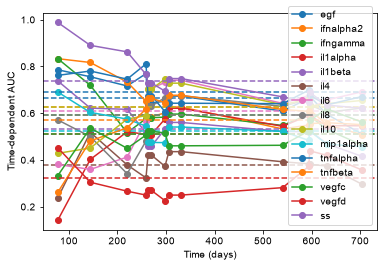

In [29]:
def plot_cumulative_dynamic_auc(risk_score, label, color=None):
    auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_score, times)
    print(f"{label}: mean AUC = {mean_auc:.3f}")

    plt.plot(times, auc, marker="o", color=color, label=label)
    plt.xlabel("Time (days)")
    plt.ylabel("Time-dependent AUC")
    plt.axhline(mean_auc, color=color, linestyle="--")
    plt.legend(loc="lower right")

# numeric_features = ["ss"]

X_test_arr = np.asarray(X_test_transformed)

for i, col in enumerate(selected_features):
    plot_cumulative_dynamic_auc(X_test_arr[:, i], col, color=f"C{i}")
    ret = concordance_index_ipcw(y_train, y_test, X_test_arr[:, i], tau=times[-1])
    # print(ret)

In [ ]:
# def plot_cumulative_dynamic_auc(risk_score, label, color=None, ax=None):
#     if ax is None:
#         ax = plt.gca()

#     auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_score, times)

#     ax.plot(times, auc, marker="o", markersize=4, linewidth=1.8, color=color, label=label)
#     ax.axhline(mean_auc, color=color, linestyle="--", linewidth=1, alpha=0.6)
#     return mean_auc

# numeric_features = ["tnfalpha", "il4", "il10", "ifnalpha2"]
# X_test_arr = np.asarray(X_test_transformed)

# fig, ax = plt.subplots(figsize=(16, 10))

# mean_aucs = []
# for i, col in enumerate(numeric_features):
#     mean_auc = plot_cumulative_dynamic_auc(X_test_arr[:, i], col, color=f"C{i}", ax=ax)
#     mean_aucs.append((col, mean_auc))
#     ret = concordance_index_ipcw(y_train, y_test, X_test_arr[:, i], tau=times[-1])

# ax.set_xlabel("Time (days)", fontsize=20)
# ax.tick_params(axis="x", labelsize=18)
# ax.set_ylabel("Time-dependent AUC", fontsize=20)
# ax.tick_params(axis="y", labelsize=18)
# ax.set_title("Time-dependent AUC by variable", fontsize=22, fontweight="bold")
# ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="Chance (AUC = 0.5)")

# # legend OUTSIDE the plot area, to the right — no overlap with lines regardless of curve shape
# ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=16, frameon=False, title="")

# plt.tight_layout()
# # fig.savefig("../figures/time_dependent_auc.png", dpi=300, bbox_inches="tight")
# plt.show()

In [ ]:
# def plot_cumulative_dynamic_auc(risk_score, label, color=None, ax=None):
#     if ax is None:
#         ax = plt.gca()

#     auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_score, times)

#     ax.plot(times, auc, marker="o", markersize=4, linewidth=1.8, color=color, label=label)
#     ax.axhline(mean_auc, color=color, linestyle="--", linewidth=1, alpha=0.6)
#     return mean_auc

# # numeric_features = ["il6", "il8", "il10", "tnfalpha", "ss"]

# X_test_arr = np.asarray(X_test_transformed)

# # --- compute mean_auc for all features first, then keep only the top 5 ---
# mean_auc_lookup = []
# for i, col in enumerate(numeric_features):
#     _, mean_auc = cumulative_dynamic_auc(y_train, y_test, X_test_arr[:, i], times)
#     mean_auc_lookup.append((col, i, mean_auc))

# top5 = sorted(mean_auc_lookup, key=lambda x: x[2], reverse=True)[:5]
# numeric_features = [col for col, i, mean_auc in top5]
# top5_indices = [i for col, i, mean_auc in top5]

# fig, ax = plt.subplots(figsize=(16, 10))

# mean_aucs = []
# for i, col in zip(top5_indices, numeric_features):
#     mean_auc = plot_cumulative_dynamic_auc(X_test_arr[:, i], col, color=f"C{i}", ax=ax)
#     mean_aucs.append((col, mean_auc))
#     ret = concordance_index_ipcw(y_train, y_test, X_test_arr[:, i], tau=times[-1])

# ax.set_xlabel("Time (days)", fontsize=20)
# ax.tick_params(axis="x", labelsize=18)
# ax.set_ylabel("Time-dependent AUC", fontsize=20)
# ax.tick_params(axis="y", labelsize=18)
# ax.set_title("Time-dependent AUC by variable", fontsize=22, fontweight="bold")
# ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="Chance (AUC = 0.5)")

# # legend OUTSIDE the plot area, to the right — no overlap with lines regardless of curve shape
# ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=16, frameon=False, title="")

# plt.tight_layout()
# # fig.savefig("../figures/time_dependent_auc_top5.png", dpi=300, bbox_inches="tight")
# plt.show()

In [30]:
X_train_transformed

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,ss
37,-0.438329,-0.469156,-1.108552,-0.437996,-0.441136,-0.881219,0.256070,0.241921,-0.054554,-0.305942,-0.456563,-0.387154,-1.003237,-0.551885,0.680232
100,-0.776768,-0.469156,0.644939,-0.283216,-0.278605,-0.131303,0.320005,1.882327,-0.031440,0.006927,0.138915,-0.026598,1.821022,0.318518,1.375923
145,-0.731886,-1.135522,-0.369744,-0.483954,-0.448971,-0.439746,-0.451610,-0.488992,-0.417580,-1.017937,-0.768502,-0.434398,-0.870063,-0.126431,0.376605
174,0.913235,-1.648148,-1.312264,-0.525837,-1.074436,-0.451083,-0.364485,-0.349853,-0.440358,-1.682758,-0.460468,-0.466784,-1.111297,-0.100590,1.139472
10,-0.811046,-0.469156,-1.472734,-0.437996,-0.441136,-1.038064,0.838763,1.334033,-0.433819,-0.305942,-0.803409,-0.115953,-1.180638,2.698556,0.680232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,-0.883465,-0.469156,-0.976849,-0.316653,-0.441136,-0.748881,-0.207656,-0.185525,-0.327063,-0.282104,0.316762,-0.326017,-0.849898,-0.062265,0.680232
53,1.596408,-0.178550,-0.381927,-0.405368,-0.338250,-0.484205,-0.026374,1.466071,5.010077,-0.152700,-0.866230,-0.326017,-0.460854,-0.057960,0.680232
108,-0.700245,-0.067254,1.977259,-0.437996,-0.312901,0.050049,0.364516,0.349342,-0.439215,-0.000877,1.391808,0.009458,1.162965,2.229398,2.071615
107,-0.213347,-0.438027,-0.007668,-0.437996,-0.441136,-0.283247,0.523138,0.284442,-0.327063,-0.228895,2.809276,-0.089303,-0.871190,1.414720,1.375923


In [31]:
X_test_transformed.head()

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,ss
91,-0.883465,-0.367028,-0.159526,-0.437996,-0.441136,-0.812599,-0.632537,0.391862,-0.487871,-0.228895,0.145109,-0.274807,-0.008774,0.477467,-0.015460
176,-0.370743,0.222547,0.262000,1.372596,0.424966,0.614415,1.350695,1.219807,1.397728,0.146973,-0.128952,0.925757,-1.059953,-0.182579,1.139472
134,0.095100,0.199838,0.030918,-0.126439,-0.046274,-0.046984,-0.083845,-0.071573,-0.246910,0.441142,0.473302,0.005244,-0.825209,-0.139312,1.902339
63,-0.307009,-0.003504,1.866059,-0.238993,-0.304700,0.912697,2.374807,0.235207,0.429938,-0.062741,0.215009,0.854415,1.406639,0.081399,0.680232
21,2.106239,-0.312233,1.431335,-0.437996,-0.409077,-0.043078,-0.555654,-0.514501,-0.470513,-0.123045,-0.364542,-0.214192,0.108424,-0.193014,1.375923


C-index: 0.677
Mean AUC: 0.787


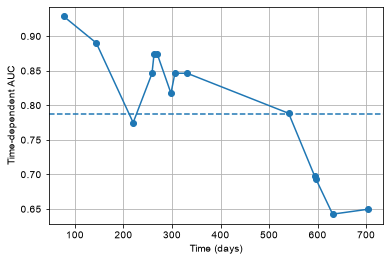

In [32]:
cph = CoxPHSurvivalAnalysis()
cph.fit(X_train_transformed, y_train)
c_index = cph.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

cph_risk_scores = cph.predict(X_test_transformed)
cph_auc, cph_mean_auc = cumulative_dynamic_auc(y_train, y_test, cph_risk_scores, times)
print(f"Mean AUC: {cph_mean_auc:.3f}")

plt.plot(times, cph_auc, marker="o")
plt.axhline(cph_mean_auc, linestyle="--")
plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.grid(True)

C-index: 0.69
Mean AUC: 0.732


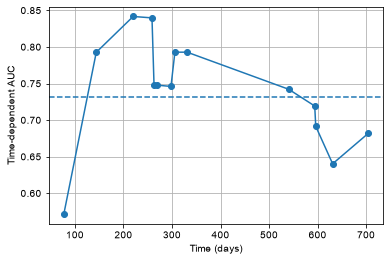

In [33]:
gbsa_tree = GradientBoostingSurvivalAnalysis(random_state=2026)
gbsa_tree.fit(X_train_transformed, y_train)
c_index = gbsa_tree.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

gbsa_tree_risk_scores = gbsa_tree.predict(X_test_transformed)
gbsa_tree_auc, gbsa_tree_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_tree_risk_scores, times)
print(f"Mean AUC: {gbsa_tree_mean_auc:.3f}")

plt.plot(times, gbsa_tree_auc, marker="o")
plt.axhline(gbsa_tree_mean_auc, linestyle="--")
plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.grid(True)

C-index: 0.679
Mean AUC: 0.770


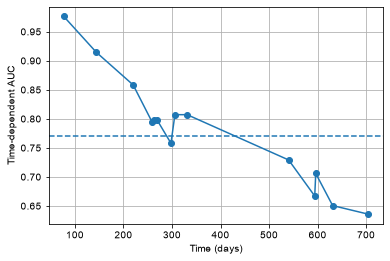

In [34]:
gbsa_ls = ComponentwiseGradientBoostingSurvivalAnalysis(random_state=2026)
gbsa_ls.fit(X_train_transformed, y_train)
cindex = gbsa_ls.score(X_test_transformed, y_test)
print(f"C-index: {round(cindex, 3)}")

gbsa_ls_risk_scores = gbsa_ls.predict(X_test_transformed)
gbsa_ls_auc, gbsa_ls_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_ls_risk_scores, times)
print(f"Mean AUC: {gbsa_ls_mean_auc:.3f}")

plt.plot(times, gbsa_ls_auc, marker="o")
plt.axhline(gbsa_ls_mean_auc, linestyle="--")
plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.grid(True)

C-index: 0.726
Mean AUC: 0.717


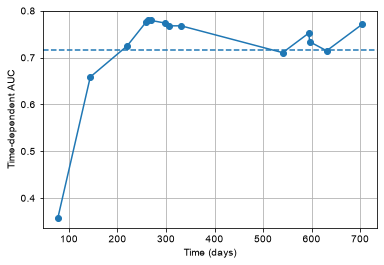

In [35]:
rsf = RandomSurvivalForest(random_state=2026)
rsf.fit(X_train_transformed, y_train)
c_index = rsf.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

rsf_risk_scores = rsf.predict(X_test_transformed)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)
print(f"Mean AUC: {rsf_mean_auc:.3f}")

plt.plot(times, rsf_auc, marker="o")
plt.axhline(rsf_mean_auc, linestyle="--")
plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.grid(True)

In [36]:
# Permutation-based feature importance
result = permutation_importance(rsf, X_test_transformed, y_test, n_repeats=15, random_state=2026)

pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test_transformed.columns,
).sort_values(by="importances_mean", ascending=False)

,importances_mean,importances_std
ss,0.103018,0.047229
vegfd,0.077366,0.051792
il6,0.017695,0.012110
il1alpha,0.014540,0.010638
tnfalpha,0.014403,0.012883
mip1alpha,0.012346,0.012550
il10,0.005350,0.009990
il8,0.002606,0.010691
ifngamma,-0.002743,0.010510
tnfbeta,-0.002881,0.008393


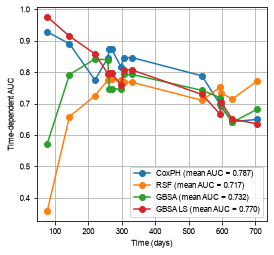

In [38]:
# Plot all models together for comparison
fig, ax = plt.subplots(figsize=(10.5, 10, "cm"), facecolor="white")
ax.set_facecolor("white")

ax.plot(times, cph_auc, "o-", label=f"CoxPH (mean AUC = {cph_mean_auc:.3f})")
ax.plot(times, rsf_auc, "o-", label=f"RSF (mean AUC = {rsf_mean_auc:.3f})")
ax.plot(times, gbsa_tree_auc, "o-", label=f"GBSA (mean AUC = {gbsa_tree_mean_auc:.3f})")
ax.plot(times, gbsa_ls_auc, "o-", label=f"GBSA LS (mean AUC = {gbsa_ls_mean_auc:.3f})")
ax.set_xlabel("Time (days)", fontsize = 8)
ax.tick_params(axis="x", labelsize=8)
ax.set_ylabel("Time-dependent AUC", fontsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.set_title("", fontsize=8, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True)

fig.savefig("../figures/time_dependent_auc_full_model_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")